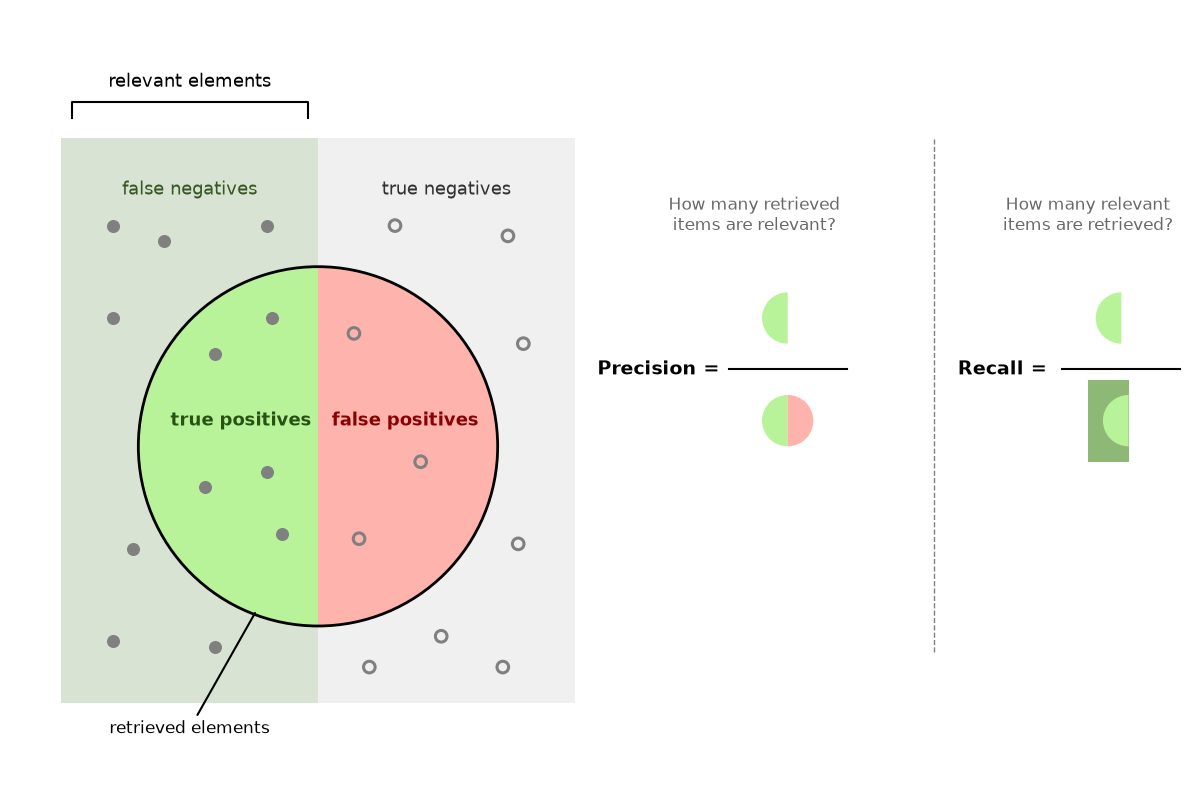

In [49]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import numpy as np

# Set up figure horizontally
fig, ax = plt.subplots(figsize=(14, 8))
ax.set_xlim(-0.1, 2.2)
ax.set_ylim(-0.15, 1.35)
ax.set_aspect('equal')
ax.axis('off')

# Color palette
bg_relevant = '#d8e3d3'      # Left background (Relevant elements)
bg_irrelevant = '#f0f0f0'    # Right background (Irrelevant elements)
tp_color = '#b8f399'         # Circle left (True Positives)
fp_color = '#ffb3ad'         # Circle right (False Positives)
fn_text_color = '#385723'
tn_text_color = '#333333'
tp_text_color = '#275214'
fp_text_color = '#8b0000'

# 1. Background Rectangles (Left side of the canvas)
ax.add_patch(patches.Rectangle((0, 0), 0.5, 1.1, facecolor=bg_relevant, edgecolor='none'))
ax.add_patch(patches.Rectangle((0.5, 0), 0.5, 1.1, facecolor=bg_irrelevant, edgecolor='none'))

# 2. Central Circle (Retrieved elements)
circle_center = (0.5, 0.5)
circle_radius = 0.35

wedge_tp = patches.Wedge(circle_center, circle_radius, 90, 270, facecolor=tp_color, edgecolor='none')
ax.add_patch(wedge_tp)

wedge_fp = patches.Wedge(circle_center, circle_radius, 270, 90, facecolor=fp_color, edgecolor='none')
ax.add_patch(wedge_fp)

circle_outline = patches.Circle(circle_center, circle_radius, fill=False, edgecolor='black', linewidth=2)
ax.add_patch(circle_outline)

# 3. Quadrant Text Labels
ax.text(0.25, 1.0, 'false negatives', color=fn_text_color, fontsize=13, ha='center', va='center')
ax.text(0.75, 1.0, 'true negatives', color=tn_text_color, fontsize=13, ha='center', va='center')
ax.text(0.35, 0.55, 'true positives', color=tp_text_color, fontsize=13, ha='center', va='center', fontweight='bold')
ax.text(0.67, 0.55, 'false positives', color=fp_text_color, fontsize=13, ha='center', va='center', fontweight='bold')

# 4. Top Bracket for "relevant elements"
ax.plot([0.02, 0.02, 0.48, 0.48], [1.14, 1.17, 1.17, 1.14], color='black', linewidth=1.5)
ax.text(0.25, 1.21, 'relevant elements', fontsize=13, ha='center', va='center')

# 5. Point Markers (Data Points)
fn_dots = [(0.1, 0.93), (0.2, 0.9), (0.4, 0.93), (0.1, 0.75), (0.14, 0.3), (0.1, 0.12), (0.3, 0.11)]
for x, y in fn_dots:
    ax.scatter(x, y, color='gray', s=70, zorder=3)

tn_dots = [(0.65, 0.93), (0.87, 0.91), (0.9, 0.7), (0.89, 0.31), (0.74, 0.13), (0.6, 0.07), (0.86, 0.07)]
for x, y in tn_dots:
    ax.scatter(x, y, facecolors='none', edgecolors='gray', linewidths=2.2, s=70, zorder=3)

tp_dots = [(0.3, 0.68), (0.41, 0.75), (0.28, 0.42), (0.4, 0.45), (0.43, 0.33)]
for x, y in tp_dots:
    ax.scatter(x, y, color='gray', s=70, zorder=3)

fp_dots = [(0.57, 0.72), (0.7, 0.47), (0.58, 0.32)]
for x, y in fp_dots:
    ax.scatter(x, y, facecolors='none', edgecolors='gray', linewidths=2.2, s=70, zorder=3)

# 6. Annotations for "retrieved elements" (Left and Right pointers)
ax.annotate('retrieved elements', xy=(0.38, 0.18), xytext=(0.25, -0.05),
            arrowprops=dict(arrowstyle='-', color='black', lw=1.5),
            fontsize=12, ha='center', va='center')

# ==============================================================================
# RIGHT SIDE: Formulas & Visual Fractions
# ==============================================================================

# Precision Section
px_center = 1.35
ax.text(px_center, 0.95, 'How many retrieved\nitems are relevant?', color='dimgray', fontsize=12, ha='center', va='center')
ax.text(px_center - 0.18, 0.65, 'Precision = ', fontsize=14, ha='center', va='center', fontweight='bold')
ax.plot([px_center - 0.05, px_center + 0.18], [0.65, 0.65], color='black', linewidth=1.5)  # Fraction bar

# Precision numerator (green semi-circle)
wedge_p_num = patches.Wedge((px_center + 0.065, 0.75), 0.05, 90, 270, facecolor=tp_color, edgecolor='none')
ax.add_patch(wedge_p_num)

# Precision denominator (full green/red circle)
wedge_p_den_l = patches.Wedge((px_center + 0.065, 0.55), 0.05, 90, 270, facecolor=tp_color, edgecolor='none')
wedge_p_den_r = patches.Wedge((px_center + 0.065, 0.55), 0.05, 270, 90, facecolor=fp_color, edgecolor='none')
ax.add_patch(wedge_p_den_l)
ax.add_patch(wedge_p_den_r)

# Horizontal/Vertical Separator
ax.plot([1.7, 1.7], [0.1, 1.1], color='gray', linewidth=1, linestyle='--')

# Recall Section
rx_center = 2
ax.text(rx_center, 0.95, 'How many relevant\nitems are retrieved?', color='dimgray', fontsize=12, ha='center', va='center')
ax.text(rx_center - 0.16, 0.65, 'Recall = ', fontsize=14, ha='center', va='center', fontweight='bold')
ax.plot([rx_center - 0.05, rx_center + 0.18], [0.65, 0.65], color='black', linewidth=1.5)  # Fraction bar

# Recall numerator (green semi-circle)
wedge_r_num = patches.Wedge((rx_center + 0.065, 0.75), 0.05, 90, 270, facecolor=tp_color, edgecolor='none')
ax.add_patch(wedge_r_num)

# Recall denominator (green box + semi-circle)
ax.add_patch(patches.Rectangle((rx_center, 0.47), 0.08, 0.16, facecolor='#8eb875', edgecolor='none'))
wedge_r_den = patches.Wedge((rx_center + 0.079, 0.55), 0.05, 90, 270, facecolor=tp_color, edgecolor='none')
ax.add_patch(wedge_r_den)

plt.tight_layout()
plt.savefig('precision_recall_horizontal.png', dpi=300, bbox_inches='tight')